# RepViT — Setup Lebih Sederhana (Plain Weighted CrossEntropy)

Versi ini adalah **koreksi** dari eksperimen RepViT sebelumnya, yang hasilnya malah lebih buruk dari MobileNet baseline (macro-F1 0.710 vs 0.787, dan bias ke Mild DR makin ekstrem). Dari situ ada 2 kecurigaan:

1. **Loss over-correction yang "tersembunyi"** — walau `WeightedRandomSampler` sudah dicabut, di dalam Focal Loss sendiri ada 2 mekanisme yang searah: `alpha` (class weight) **dan** `gamma` (focusing ke sample sulit). Keduanya sama-sama mendorong ke arah kelas sulit/minoritas, jadi tetap bisa overshoot walau sampler sudah tidak dipakai.
2. **Kemungkinan underfitting** — `train_acc` mentok di ~0.68 sampai epoch 36 (bandingkan MobileNet yang sampai 0.834). `LR` awal `3e-5` sudah konservatif, lalu `ReduceLROnPlateau` (patience=3) menurunkannya lagi beberapa kali sampai `3.8e-6` di epoch 30-an — LR keburu "beku" sebelum model benar-benar sempat belajar, apalagi dengan preprocessing (green-channel CLAHE) yang cukup mengubah statistik piksel dari yang diharapkan bobot pretrained.

## Perubahan di notebook ini (semua untuk menyederhanakan & menghilangkan confound)

- **Loss → plain weighted CrossEntropyLoss** (ganti Focal Loss). Cuma 1 mekanisme koreksi imbalance (`weight`), tidak ada `gamma` yang menambah dorongan kedua ke arah yang sama.
- **LR dinaikkan** ke nilai yang lebih wajar untuk fine-tuning model pretrained di resolusi tinggi.
- **Scheduler diganti ke `CosineAnnealingLR`** (bukan `ReduceLROnPlateau`) — LR menurun *smooth* & terjadwal sepanjang training, tidak bereaksi ke noise val_f1 per-epoch dan tidak akan "beku" prematur seperti kemarin.
- **Early stopping patience dinaikkan** — kasih model lebih banyak ruang untuk konvergen sebelum training dihentikan.
- Resolusi tinggi (384) & green-channel enhancement **tetap dipertahankan** — supaya kita masih bisa menjawab pertanyaan awal (apakah itu membantu), dengan setup training yang sekarang lebih adil dibanding MobileNet baseline.

## Yang berubah dari eksperimen MobileNet sebelumnya

1. **Arsitektur → RepViT** (`repvit_m1`, via `timm`). RepViT punya komponen attention, secara desain lebih baik menangkap fitur lokal-halus & hubungan spasial dibanding CNN murni (MobileNet/EfficientNet/GhostNet — tiga-tiganya sudah dicoba dan hasilnya mirip semua, jadi ini percobaan pertama pakai arsitektur berbeda paradigma).
2. **Resolusi input naik**: 224/288 → **384**. Microaneurysm bisa cuma beberapa piksel; resize terlalu kecil bisa "menghapus" lesi itu sebelum sempat dipelajari model. RepViT sepenuhnya konvolusional setelah re-parameterization, jadi aman dipakai di resolusi lebih tinggi dari 224 (tidak seperti ViT murni yang butuh interpolasi positional embedding).
3. **Green-channel enhancement**: di fundus imaging, channel hijau punya kontras tertinggi untuk hemorrhage/microaneurysm (dasar dari teknik "red-free imaging" yang dipakai dokter mata). Kita terapkan CLAHE lebih kuat khusus di channel hijau, bukan cuma di L-channel LAB seperti sebelumnya.
4. **Cuma SATU mekanisme koreksi imbalance** (loss weighting), **tidak dobel** dengan sampler. Ini pelajaran dari eksperimen sebelumnya: sampler + weighted loss sekaligus bikin decision boundary overshoot (recall Mild naik tapi presisi jatuh, dan Moderate recall ambruk). Sekarang kita jaga supaya cuma 1 mekanisme yang jalan, supaya kalau ada perubahan performa, jelas penyebabnya bukan "dobel kompensasi" lagi.
5. Split train/val pakai `SEED` & `VAL_SIZE` yang **sama** dengan notebook audit sebelumnya, supaya val set-nya identik dan hasilnya bisa dibandingkan apple-to-apple.

## Catatan sebelum jalan

- Resolusi 384 + RepViT butuh memory lebih besar dari MobileNet 288 kemarin. `BATCH_SIZE` diturunkan ke 16 sebagai default aman; naikkan kalau GPU/memory kamu cukup lega, turunkan kalau OOM.
- Kalau `timm` versi kamu tidak punya `repvit_m1`, update dulu: `pip install -U timm`. Nama model RepViT lain yang bisa dicoba: `repvit_m0_9`, `repvit_m1_1`, `repvit_m1_5`, `repvit_m2_3` (makin besar angkanya, makin besar modelnya).


In [1]:
# ==== 1. INSTALL DEPENDENCIES ====
%pip install -q torch torchvision timm opencv-python-headless scikit-learn matplotlib seaborn pandas tqdm pillow


Note: you may need to restart the kernel to use updated packages.


In [2]:
# ==== 2. IMPORTS ====
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm

from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")
print("Torch:", torch.__version__, "| timm:", timm.__version__)


Torch: 2.13.0 | timm: 1.0.9


In [3]:
# ==== 3. KONFIGURASI & PATH DATASET (per kelas) ====

CLASS_PATHS = {
    "Normal":            "/Users/mymac/Downloads/Diabetic Retinopathy and Retinal Diseases Fundus I/11.Normal Fundus",
    "Mild DR":           "/Users/mymac/Downloads/Diabetic Retinopathy and Retinal Diseases Fundus I/3.Mild DR",
    "Moderate DR":       "/Users/mymac/Downloads/Diabetic Retinopathy and Retinal Diseases Fundus I/4.Moderate DR",
    "Severe DR":         "/Users/mymac/Downloads/Diabetic Retinopathy and Retinal Diseases Fundus I/5.Severe DR",
    "Very Severe NPDR":  "/Users/mymac/Downloads/Diabetic Retinopathy and Retinal Diseases Fundus I/13. Very Severe NPDR",
    "PDR":               "/Users/mymac/Downloads/Diabetic Retinopathy and Retinal Diseases Fundus I/6.Proliferate DR",
    "Advanced PDR":      "/Users/mymac/Downloads/Diabetic Retinopathy and Retinal Diseases Fundus I/12. Advanced PDR",
}

CONFIG = {
    "OUTPUT_DIR": "./outputs",
    "MODEL_NAME": "repvit_m1.dist_in1k",   # ganti ke repvit_m0_9 / repvit_m1_1 / dst kalau perlu
    "IMG_SIZE": 384,          # naik dari 288 -> lesi kecil lebih kejaga
    "BATCH_SIZE": 16,         # diturunkan karena resolusi & model lebih berat
    "NUM_WORKERS": 0,         # aman untuk notebook/macOS (spawn multiprocessing issue)
    "VAL_SIZE": 0.2,          # SAMA dengan notebook audit -> val set identik
    "SEED": 42,               # SAMA dengan notebook audit -> val set identik
    "EPOCHS": 40,
    "LR": 1e-4,               # dinaikkan dari 3e-5 -> lebih wajar untuk fine-tune di resolusi tinggi
    "WEIGHT_DECAY": 1e-4,
    "LABEL_SMOOTHING": 0.05,
    "USE_GREEN_ENHANCE": True,
    "EARLY_STOP_PATIENCE": 12,  # dinaikkan -> kasih model ruang lebih untuk konvergen
    "LR_MIN": 1e-6,             # LR minimum di akhir cosine schedule
    "AMP": True,               # cuma aktif kalau CUDA tersedia
}

os.makedirs(CONFIG["OUTPUT_DIR"], exist_ok=True)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():   # Apple Silicon (M1/M2/M3)
    device = torch.device("mps")
else:
    device = torch.device("cpu")

USE_PIN_MEMORY = (device.type == "cuda")
USE_AMP = CONFIG["AMP"] and (device.type == "cuda")
print("Device:", device, "| AMP aktif:", USE_AMP)


Device: mps | AMP aktif: False


In [4]:
# ==== 4. SCAN DATASET ====

VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

class_names = sorted(CLASS_PATHS.keys())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

records = []
for cls, folder in CLASS_PATHS.items():
    cls_dir = Path(folder)
    assert cls_dir.exists(), f"Folder tidak ditemukan untuk kelas '{cls}': {cls_dir}"
    for fp in cls_dir.rglob("*"):
        if fp.is_file() and fp.suffix.lower() in VALID_EXT:
            records.append({"filepath": str(fp), "label_name": cls, "label": class_to_idx[cls]})

df = pd.DataFrame(records)
assert len(df) > 0, "Tidak ada gambar terbaca. Cek kembali path di CLASS_PATHS."

NUM_CLASSES = len(class_names)
print(f"Total gambar: {len(df)} | Jumlah kelas: {NUM_CLASSES}")

dist = df["label_name"].value_counts().reindex(class_names)
print("\nDistribusi kelas:")
print(dist)


Total gambar: 14514 | Jumlah kelas: 7

Distribusi kelas:
label_name
Advanced PDR         114
Mild DR             2441
Moderate DR         5368
Normal              3061
PDR                 1504
Severe DR           1918
Very Severe NPDR     108
Name: count, dtype: int64


In [5]:
# ==== 5. SPLIT TRAIN / VAL (stratified, identik dengan notebook audit) ====

train_df, val_df = train_test_split(
    df, test_size=CONFIG["VAL_SIZE"], stratify=df["label"], random_state=CONFIG["SEED"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)}")
print("\nDistribusi train:")
print(train_df["label_name"].value_counts().reindex(class_names))
print("\nDistribusi val:")
print(val_df["label_name"].value_counts().reindex(class_names))


Train: 11611 | Val: 2903

Distribusi train:
label_name
Advanced PDR          91
Mild DR             1953
Moderate DR         4294
Normal              2449
PDR                 1203
Severe DR           1534
Very Severe NPDR      87
Name: count, dtype: int64

Distribusi val:
label_name
Advanced PDR          23
Mild DR              488
Moderate DR         1074
Normal               612
PDR                  301
Severe DR            384
Very Severe NPDR      21
Name: count, dtype: int64


In [6]:
# ==== 6. PREPROCESSING: GREEN-CHANNEL ENHANCEMENT + TRANSFORM ====

def enhance_green_channel(img_rgb):
    # Channel hijau punya kontras tertinggi untuk microaneurysm/hemorrhage di fundus
    # (dasar teknik "red-free imaging"). CLAHE diterapkan lebih kuat khusus di channel
    # hijau, R & B dapat CLAHE ringan supaya warna tetap natural.
    r, g, b = cv2.split(img_rgb)

    clahe_strong = cv2.createCLAHE(clipLimit=3.5, tileGridSize=(8, 8))
    clahe_mild = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))

    g_enh = clahe_strong.apply(g)
    r_enh = clahe_mild.apply(r)
    b_enh = clahe_mild.apply(b)

    return cv2.merge((r_enh, g_enh, b_enh))


IMG_SIZE = CONFIG["IMG_SIZE"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


In [7]:
# ==== 7. DATASET & DATALOADER ====

class DRDataset(Dataset):
    def __init__(self, dataframe, transform=None, use_green_enhance=True):
        self.paths = dataframe["filepath"].values
        self.labels = dataframe["label"].values
        self.transform = transform
        self.use_green_enhance = use_green_enhance

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.use_green_enhance:
            img = enhance_green_channel(img)
        img = Image.fromarray(img)

        label = int(self.labels[idx])
        if self.transform:
            img = self.transform(img)
        return img, label


train_ds = DRDataset(train_df, transform=train_transform, use_green_enhance=CONFIG["USE_GREEN_ENHANCE"])
val_ds = DRDataset(val_df, transform=eval_transform, use_green_enhance=CONFIG["USE_GREEN_ENHANCE"])

# Catatan: sengaja TIDAK pakai WeightedRandomSampler di sini -> cuma loss weighting
# yang jadi satu-satunya mekanisme koreksi imbalance (lihat catatan di cell 9).
train_loader = DataLoader(
    train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True,
    num_workers=CONFIG["NUM_WORKERS"], pin_memory=USE_PIN_MEMORY, drop_last=True
)
val_loader = DataLoader(
    val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False,
    num_workers=CONFIG["NUM_WORKERS"], pin_memory=USE_PIN_MEMORY
)

print(f"Batches -> train: {len(train_loader)} | val: {len(val_loader)}")


Batches -> train: 725 | val: 182


In [8]:
# ==== 8. MODEL: RepViT (timm, pretrained) ====

model = timm.create_model(CONFIG["MODEL_NAME"], pretrained=True, num_classes=NUM_CLASSES)
model = model.to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {CONFIG['MODEL_NAME']} | Total params: {n_params/1e6:.2f}M")


Model: repvit_m1.dist_in1k | Total params: 4.72M


In [9]:
# ==== 9. LOSS (plain weighted CrossEntropy) & OPTIMIZER ====
# CATATAN PENTING: cuma pakai SATU mekanisme koreksi imbalance (weight di CrossEntropy).
# TIDAK pakai Focal Loss lagi -> di eksperimen sebelumnya, alpha (class weight) dan
# gamma (focusing ke sample sulit) di Focal Loss sama-sama mendorong ke arah yang sama
# (kelas sulit/minoritas), jadi walau WeightedRandomSampler sudah dicabut, kombinasi
# alpha+gamma itu sendiri tetap bisa overshoot. Sekarang benar-benar cuma 1 sinyal koreksi.

cls_counts = df["label"].value_counts().sort_index().values.astype(np.float32)
inv_freq = 1.0 / cls_counts
class_weights = inv_freq / inv_freq.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights untuk loss:")
for c, w in zip(class_names, class_weights.cpu().numpy()):
    print(f"  {c:20s}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=CONFIG["LABEL_SMOOTHING"])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["LR"], weight_decay=CONFIG["WEIGHT_DECAY"])

# CosineAnnealingLR: LR turun smooth & terjadwal sepanjang training, TIDAK bereaksi ke
# noise val_f1 per-epoch seperti ReduceLROnPlateau kemarin (yang bikin LR "beku"
# prematur di epoch 20-an sebelum model sempat konvergen).
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG["EPOCHS"], eta_min=CONFIG["LR_MIN"]
)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)


Class weights untuk loss:
  Advanced PDR        : 3.049
  Mild DR             : 0.142
  Moderate DR         : 0.065
  Normal              : 0.114
  PDR                 : 0.231
  Severe DR           : 0.181
  Very Severe NPDR    : 3.218


In [10]:
# ==== 10. EARLY STOPPING ====

class EarlyStopping:
    def __init__(self, patience=7, mode="max"):
        self.patience = patience
        self.mode = mode
        self.best_score = None
        self.counter = 0
        self.should_stop = False

    def step(self, score):
        if self.best_score is None:
            self.best_score = score
            return True
        improved = (score > self.best_score) if self.mode == "max" else (score < self.best_score)
        if improved:
            self.best_score = score
            self.counter = 0
            return True
        self.counter += 1
        if self.counter >= self.patience:
            self.should_stop = True
        return False


early_stopper = EarlyStopping(patience=CONFIG["EARLY_STOP_PATIENCE"], mode="max")
best_ckpt_path = os.path.join(CONFIG["OUTPUT_DIR"], f"best_{CONFIG['MODEL_NAME'].split('.')[0]}_simple.pt")


In [11]:
# ==== 11. FUNGSI TRAIN 1 EPOCH & VALIDASI (dengan progress bar, AMP) ====

def train_one_epoch(model, loader, criterion, optimizer, scaler, device, epoch, total_epochs):
    model.train()
    running_loss, running_correct, seen = 0.0, 0, 0

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [train]", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast("cuda", enabled=scaler.is_enabled()):
            logits = model(imgs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = labels.size(0)
        running_loss += loss.item() * bs
        running_correct += (logits.argmax(1) == labels).sum().item()
        seen += bs

        pbar.set_postfix(loss=f"{running_loss/seen:.4f}", acc=f"{running_correct/seen:.4f}")

    return running_loss / seen, running_correct / seen


@torch.no_grad()
def evaluate(model, loader, criterion, device, epoch, total_epochs):
    model.eval()
    running_loss, seen = 0.0, 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=f"Epoch {epoch}/{total_epochs} [val]", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)

        bs = labels.size(0)
        running_loss += loss.item() * bs
        seen += bs

        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix(loss=f"{running_loss/seen:.4f}", acc=f"{accuracy_score(all_labels, all_preds):.4f}")

    avg_loss = running_loss / seen
    acc = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average="macro")
    f1_per_class = f1_score(all_labels, all_preds, average=None, labels=list(range(NUM_CLASSES)))
    return avg_loss, acc, f1_macro, f1_per_class, all_preds, all_labels


In [12]:
# ==== 12. TRAINING LOOP (progress bar per epoch + LR scheduler + early stopping) ====

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": [], "lr": []}

epoch_bar = tqdm(range(1, CONFIG["EPOCHS"] + 1), desc="Training", unit="epoch")

for epoch in epoch_bar:
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scaler, device, epoch, CONFIG["EPOCHS"]
    )
    val_loss, val_acc, val_f1, val_f1_per_class, _, _ = evaluate(
        model, val_loader, criterion, device, epoch, CONFIG["EPOCHS"]
    )

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()  # CosineAnnealingLR: step tiap epoch, tidak bergantung ke val_f1

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)
    history["lr"].append(current_lr)

    dt = time.time() - t0
    epoch_bar.set_postfix(
        train_loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}",
        val_acc=f"{val_acc:.4f}", val_f1=f"{val_f1:.4f}", lr=f"{current_lr:.1e}"
    )
    tqdm.write(
        f"[Epoch {epoch:02d}/{CONFIG['EPOCHS']}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} val_f1(macro)={val_f1:.4f} | "
        f"lr={current_lr:.1e} | {dt:.1f}s"
    )
    mild_idx = class_to_idx.get("Mild DR")
    moderate_idx = class_to_idx.get("Moderate DR")
    if mild_idx is not None and moderate_idx is not None:
        tqdm.write(
            f"  f1 Mild DR={val_f1_per_class[mild_idx]:.4f} | f1 Moderate DR={val_f1_per_class[moderate_idx]:.4f}"
        )

    improved = early_stopper.step(val_f1)
    if improved:
        torch.save({
            "model_state_dict": model.state_dict(),
            "config": CONFIG,
            "class_to_idx": class_to_idx,
            "epoch": epoch,
            "val_f1": val_f1,
        }, best_ckpt_path)
        tqdm.write(f"  -> val_f1 membaik ({val_f1:.4f}), checkpoint disimpan ke {best_ckpt_path}")

    if early_stopper.should_stop:
        tqdm.write(f"Early stopping di epoch {epoch} (val_f1 tidak membaik {CONFIG['EARLY_STOP_PATIENCE']}x berturut-turut).")
        break

print("\nTraining selesai. Best val_f1(macro):", early_stopper.best_score)


Training:   0%|          | 0/40 [00:00<?, ?epoch/s]

Epoch 1/40 [train]:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 1/40 [val]:   0%|          | 0/182 [00:00<?, ?it/s]

[Epoch 01/40] train_loss=1.8848 train_acc=0.5909 | val_loss=1.6253 val_acc=0.6979 val_f1(macro)=0.6264 | lr=1.0e-04 | 474.7s
  f1 Mild DR=0.5745 | f1 Moderate DR=0.6134
  -> val_f1 membaik (0.6264), checkpoint disimpan ke ./outputs/best_repvit_m1_simple.pt


Epoch 2/40 [train]:   0%|          | 0/725 [00:00<?, ?it/s]

...

Epoch 35/40 [val]:   0%|          | 0/182 [00:00<?, ?it/s]

[Epoch 35/40] train_loss=1.1541 train_acc=0.9607 | val_loss=1.4089 val_acc=0.8288 val_f1(macro)=0.7808 | lr=6.4e-06 | 474.5s
  f1 Mild DR=0.6371 | f1 Moderate DR=0.7839


Epoch 36/40 [train]:   0%|          | 0/725 [00:00<?, ?it/s]

Epoch 36/40 [val]:   0%|          | 0/182 [00:00<?, ?it/s]

[Epoch 36/40] train_loss=1.1469 train_acc=0.9625 | val_loss=1.4133 val_acc=0.8309 val_f1(macro)=0.7806 | lr=4.8e-06 | 474.7s
  f1 Mild DR=0.6244 | f1 Moderate DR=0.7913
Early stopping di epoch 36 (val_f1 tidak membaik 12x berturut-turut).

Training selesai. Best val_f1(macro): 0.819794056293891


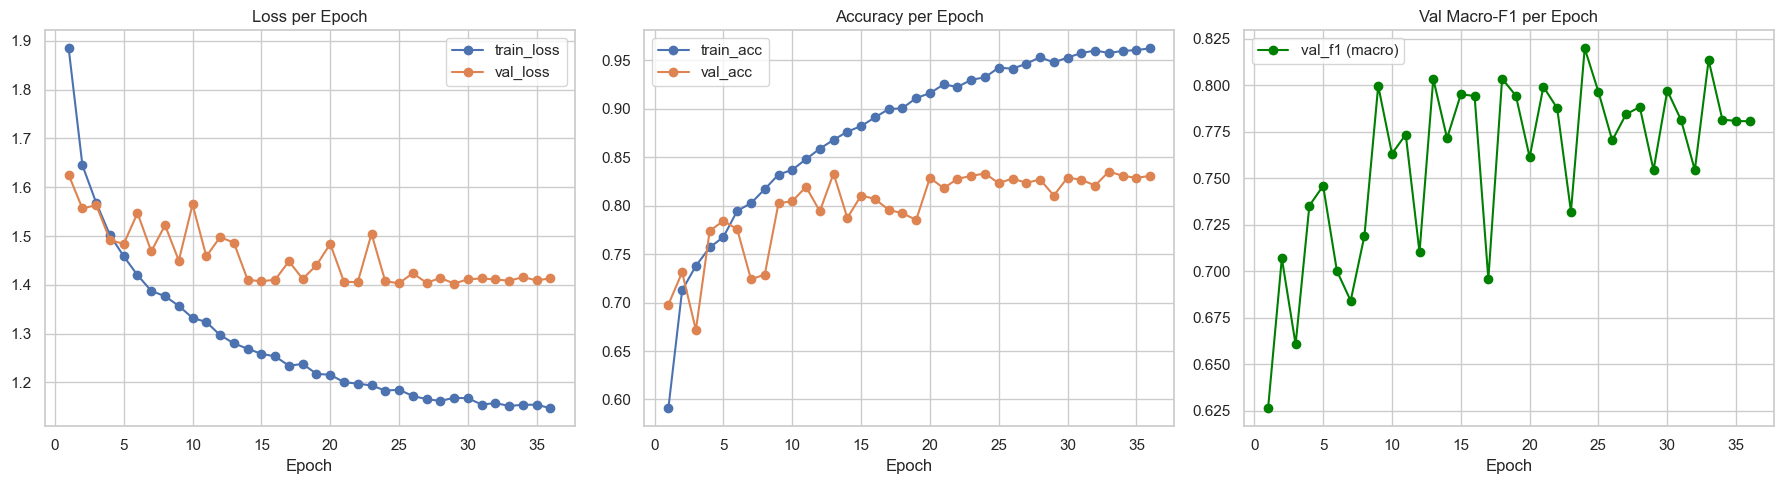

In [13]:
# ==== 13. PLOT KURVA TRAINING ====

epochs_ran = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_ran, history["train_loss"], label="train_loss", marker="o")
axes[0].plot(epochs_ran, history["val_loss"], label="val_loss", marker="o")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_ran, history["train_acc"], label="train_acc", marker="o")
axes[1].plot(epochs_ran, history["val_acc"], label="val_acc", marker="o")
axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(epochs_ran, history["val_f1"], label="val_f1 (macro)", marker="o", color="green")
axes[2].set_title("Val Macro-F1 per Epoch")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()


Loaded best checkpoint dari epoch 24 (val_f1=0.8198)


Epoch 1/1 [val]:   0%|          | 0/182 [00:00<?, ?it/s]


Val -> loss: 1.4071 | acc: 0.8333 | macro-F1: 0.8198

                  precision    recall  f1-score   support

    Advanced PDR      0.900     0.783     0.837        23
         Mild DR      0.581     0.680     0.627       488
     Moderate DR      0.824     0.759     0.790      1074
          Normal      0.997     0.997     0.997       612
             PDR      0.911     0.914     0.912       301
       Severe DR      0.953     0.906     0.929       384
Very Severe NPDR      0.477     1.000     0.646        21

        accuracy                          0.833      2903
       macro avg      0.806     0.863     0.820      2903
    weighted avg      0.844     0.833     0.837      2903



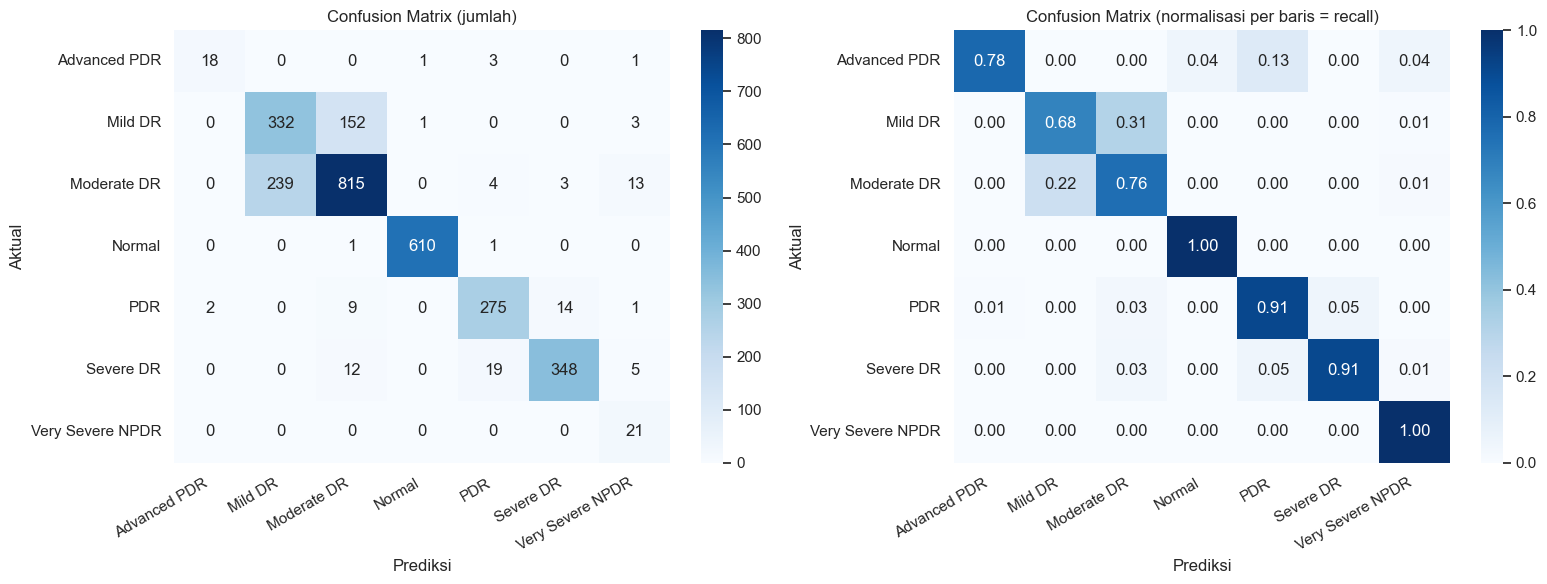

In [14]:
# ==== 14. EVALUASI DENGAN BEST CHECKPOINT ====

ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best checkpoint dari epoch {ckpt['epoch']} (val_f1={ckpt['val_f1']:.4f})")

val_loss, val_acc, val_f1, val_f1_per_class, val_preds, val_labels = evaluate(
    model, val_loader, criterion, device, 1, 1
)

print(f"\nVal -> loss: {val_loss:.4f} | acc: {val_acc:.4f} | macro-F1: {val_f1:.4f}\n")
print(classification_report(val_labels, val_preds, target_names=class_names, digits=3, zero_division=0))

cm = confusion_matrix(val_labels, val_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title("Confusion Matrix (jumlah)")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title("Confusion Matrix (normalisasi per baris = recall)")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()


In [15]:
# ==== 15. SIMPAN MODEL FINAL ====

final_path = os.path.join(CONFIG["OUTPUT_DIR"], f"final_{CONFIG['MODEL_NAME'].split('.')[0]}_simple.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "history": history,
    "config": CONFIG,
}, final_path)

print("Model tersimpan di:", final_path)


Model tersimpan di: ./outputs/final_repvit_m1_simple.pt


## Cara baca hasil ini

Bandingkan 3 hasil yang sekarang sudah ada (val set identik, `SEED`/`VAL_SIZE` sama semua):

| | MobileNetV3-Large (baseline) | RepViT + Focal Loss (kemarin) | RepViT + weighted CE (ini) |
|---|---:|---:|---:|
| train_acc akhir | 0.834 | ~0.68 (underfitting) | ? |
| val macro-F1 | 0.787 | 0.710 | ? |
| Mild DR recall/precision | 0.537 / 0.541 | 0.951 / 0.392 (overshoot) | ? |
| Moderate DR recall/precision | 0.777 / 0.775 | 0.293 / 0.903 (ambruk) | ? |

**Yang perlu dicek pertama:** apakah `train_acc` sekarang jauh lebih tinggi dari ~0.68 kemarin? Kalau iya, berarti dugaan underfitting kita benar, dan sekarang RepViT punya kesempatan adil untuk dibandingkan kapasitasnya dengan MobileNet. Kalau `train_acc` masih rendah, kemungkinan resolusi 384 + RepViT butuh lebih dari 40 epoch, atau ada bottleneck lain yang perlu digali lagi.

Kalau setup yang lebih adil ini hasilnya **masih mirip/tidak lebih baik** dari MobileNet baseline, itu bukti makin kuat masalahnya di data/label (Mild vs Moderate memang ambigu di dataset ini) — bukan lagi soal arsitektur atau training setup.
